In [14]:
import pandas as pd

# 1. Загружаем (убедись, что файл лежит в той же папке)
df = pd.read_csv('sample_data/student-mat.csv', sep=';') 

# 2. Создаем бинарный таргет
df["success"] = (df["G3"] >= 10).astype(int)

In [15]:
# Удаляем целевые колонки и промежуточные оценки из признаков
X = df.drop(['success', 'G3', 'G1', 'G2'], axis=1)
y = df['success']

# Превращаем текст в колонки 0 и 1
X = pd.get_dummies(X, drop_first=True)

print(f"Количество признаков после обработки: {X.shape[1]}")

Количество признаков после обработки: 39


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Инициализируем и обучаем
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Модель обучена!")

Модель обучена!


In [18]:
from sklearn.metrics import classification_report, accuracy_score

predictions = model.predict(X_test)

print(f"Точность модели: {accuracy_score(y_test, predictions):.2%}")
print("\nДетальный отчет:")
print(classification_report(y_test, predictions))

Точность модели: 65.82%

Детальный отчет:
              precision    recall  f1-score   support

           0       0.50      0.19      0.27        27
           1       0.68      0.90      0.78        52

    accuracy                           0.66        79
   macro avg       0.59      0.54      0.52        79
weighted avg       0.62      0.66      0.60        79



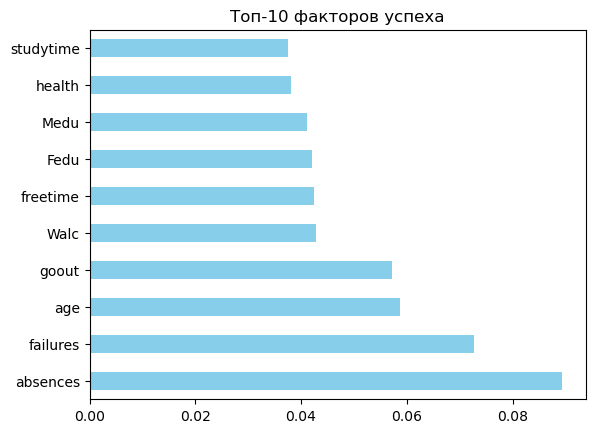

In [19]:
import matplotlib.pyplot as plt

# Берем важность признаков
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Топ-10 факторов успеха")
plt.show()

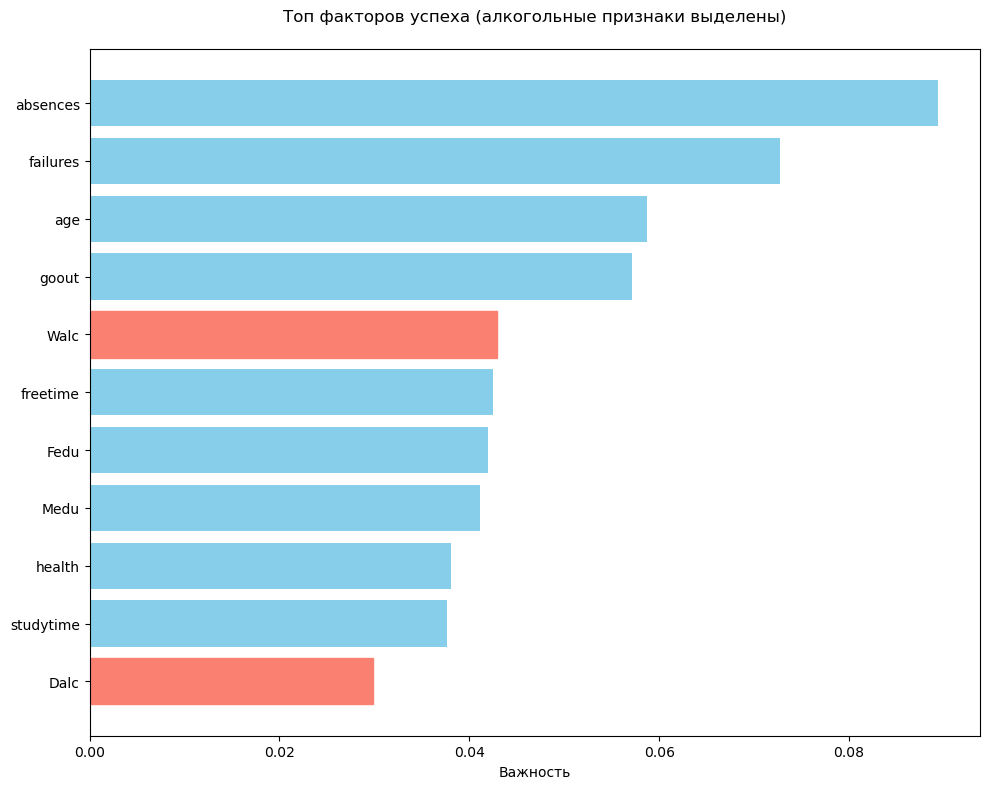


Важность алкогольных признаков:
Dalc: 0.0299
Walc: 0.0429


In [20]:
# Создаем график важности признаков
plt.figure(figsize=(10, 8))

# Берем топ-10 признаков
top_features = importances.nlargest(10)

# Проверяем, входят ли Dalc и Walc в топ-10
alcohol_features = ['Dalc', 'Walc']
for feature in alcohol_features:
    if feature in importances and feature not in top_features.index:
        # Добавляем Dalc и Walc в список, если их еще нет в топ-10
        top_features[feature] = importances[feature]

# Сортируем по убыванию важности
top_features = top_features.sort_values()

# Создаем график
bars = plt.barh(top_features.index, top_features.values, color='skyblue')

# Подсвечиваем алкогольные признаки другим цветом
for i, feature in enumerate(top_features.index):
    if feature in alcohol_features:
        bars[i].set_color('salmon')

plt.title("Топ факторов успеха (алкогольные признаки выделены)", pad=20)
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# Выводим точные значения важности для Dalc и Walc
print("\nВажность алкогольных признаков:")
for feature in alcohol_features:
    if feature in importances:
        print(f"{feature}: {importances[feature]:.4f}")
    else:
        print(f"{feature}: признак не найден в данных")